In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statistics as st


In [35]:
upi_Txn = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\upi_transaction_history.xlsx")
customer_detail = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\customer_master.xlsx")
upi_acc = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\upi_account_details.xlsx")
device_info = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\device_info.xlsx")
merchant_info = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\merchant_info.xlsx")
fraud_alert_his = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\fraud_alert_history.xlsx")
custo_feed_sur = pd.read_excel(r"C:\Users\Anurag\Downloads\Capstone excel\customer_feedback_surveys.xlsx")

In [36]:
upi_Txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   transaction_id          100000 non-null  object 
 1   upi_id                  100000 non-null  object 
 2   UPI Validation          100000 non-null  object 
 3   customer_id             100000 non-null  object 
 4   Customer validation     100000 non-null  object 
 5   timestamp               100000 non-null  object 
 6   amount                  100000 non-null  float64
 7   transaction_type        100000 non-null  object 
 8   merchant_id             30149 non-null   object 
 9   Merchant_ID validation  100000 non-null  object 
 10  counterparty_upi        100000 non-null  object 
 11  status                  100000 non-null  object 
 12  device_id               100000 non-null  object 
 13  Device Validation       100000 non-null  object 
 14  device_type          

In [37]:
upi_Txn.isnull().sum()

transaction_id                0
upi_id                        0
UPI Validation                0
customer_id                   0
Customer validation           0
timestamp                     0
amount                        0
transaction_type              0
merchant_id               69851
Merchant_ID validation        0
counterparty_upi              0
status                        0
device_id                     0
Device Validation             0
device_type                   0
channel                       0
fraud_flag                    0
reversal_flag                 0
Fraud detection               0
failure_reason            94129
Risk Score                    0
dtype: int64

In [38]:
upi_Txn["merchant_id"]= upi_Txn['merchant_id'].fillna('P2P transaction')

In [39]:
upi_Txn.isnull().sum()

transaction_id                0
upi_id                        0
UPI Validation                0
customer_id                   0
Customer validation           0
timestamp                     0
amount                        0
transaction_type              0
merchant_id                   0
Merchant_ID validation        0
counterparty_upi              0
status                        0
device_id                     0
Device Validation             0
device_type                   0
channel                       0
fraud_flag                    0
reversal_flag                 0
Fraud detection               0
failure_reason            94129
Risk Score                    0
dtype: int64

In [40]:
upi_Txn["failure_reason"]= upi_Txn['failure_reason'].fillna('Success')

In [41]:
upi_Txn.isnull().sum()

transaction_id            0
upi_id                    0
UPI Validation            0
customer_id               0
Customer validation       0
timestamp                 0
amount                    0
transaction_type          0
merchant_id               0
Merchant_ID validation    0
counterparty_upi          0
status                    0
device_id                 0
Device Validation         0
device_type               0
channel                   0
fraud_flag                0
reversal_flag             0
Fraud detection           0
failure_reason            0
Risk Score                0
dtype: int64

In [42]:
customer_detail.isnull().sum()
upi_acc.isnull().sum()
device_info.isnull().sum()
merchant_info.isnull().sum()
fraud_alert_his.dtypes


alert_id                     object
transaction_id               object
Transaction id validation    object
alert_type                   object
alert_date                   object
resolved                       bool
resolution_date              object
remarks                      object
dtype: object

In [43]:
fraud_alert_his["resolution_date"]= fraud_alert_his['resolution_date'].fillna('Pending')

In [44]:
fraud_alert_his.head()

,alert_id,transaction_id,Transaction id validation,alert_type,alert_date,resolved,resolution_date,remarks
0,alert134117,txn10034117,Valid,frequent_failure,00:29:59,False,Pending,Strategy forward the risk necessary company re...
1,alert183925,txn10083925,Valid,frequent_failure,00:41:15.200000,True,00:41:15.200000,Art do federal short.
2,alert163439,txn10063439,Valid,unusual_time,00:23:55.900000,True,00:23:55.900000,Age board fine participant join.
3,alert164967,txn10064967,Valid,frequent_failure,00:50:16.900000,True,00:50:16.900000,Among doctor much physical interest catch.
4,alert159661,txn10059661,Valid,frequent_failure,00:59:36.200000,True,00:59:36.200000,Would catch themselves be represent why decade.


In [45]:
# NOrmalize


# Normalize transaction amount
upi_Txn['amount_normalized'] = (
    (upi_Txn['amount'] - upi_Txn['amount'].min()) /
    (upi_Txn['amount'].max() - upi_Txn['amount'].min())
)

# Normalize customer risk score

customer_detail['risk_normalized'] = (
    (customer_detail['risk_score'] - customer_detail['risk_score'].min()) /
    (customer_detail['risk_score'].max() - customer_detail['risk_score'].min())
)

# Normalize merchant risk score

merchant_info['risk_normalized'] = (
    (merchant_info['risk_score'] - merchant_info['risk_score'].min()) /
    (merchant_info['risk_score'].max() - merchant_info['risk_score'].min())
)

In [46]:
customer_detail.head()

,customer_id,full_name,mobile_number,age,gender,region,date_joined,is_business_user,risk_score,risk_normalized
0,cust100000,Ryan Gallagher,7631706690,26,female,north,2024-01-28,False,0.39,0.573529
1,cust100001,Robert Garza,806360837,49,female,west,2025-04-16,False,0.13,0.191176
2,cust100002,Haley Rhodes,8124158683,68,male,west,2022-02-10,True,0.14,0.205882
3,cust100003,Sonya Mathis,3662585178,42,male,north,2021-02-18,False,0.07,0.102941
4,cust100004,Ryan Wood,9996228303,35,female,south,2023-04-17,False,0.30,0.441176


In [47]:
merchant_info.head()

,merchant_id,merchant_name,merchant_type,region,onboard_date,risk_score,risk_normalized
0,merch1000,Anderson Inc,grocery,north,2022-01-14,0.07,0.14
1,merch1001,"Rojas, Newton and White",online,north,2021-08-20,0.29,0.58
2,merch1002,Knox-Reyes,food,west,2024-10-29,0.20,0.40
3,merch1003,"Joseph, Serrano and Gilmore",grocery,north,2023-07-22,0.14,0.28
4,merch1004,Brown-Jones,food,north,2024-01-02,0.32,0.64


In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

upi_Txn['amount_standardized'] = scaler.fit_transform(
    upi_Txn[['amount']]
)


#standarization in risk score

customer_detail['risk_standardized'] = scaler.fit_transform(
    customer_detail[['risk_score']]
)

#standarization in  merchant risk score

merchant_info['risk_standardized'] = scaler.fit_transform(
    merchant_info[['risk_score']]
)

In [50]:
upi_Txn.head()

,transaction_id,upi_id,UPI Validation,customer_id,Customer validation,timestamp,amount,transaction_type,merchant_id,Merchant_ID validation,...,Device Validation,device_type,channel,fraud_flag,reversal_flag,Fraud detection,failure_reason,Risk Score,amount_normalized,amount_standardized
0,txn10000000,marisa9078@upi,Valid,cust101488,Valid,00:36:19.600000,9.88,send,P2P transaction,Not available,...,Valid,feature_phone,app,False,False,No Fraud Detection,Success,0.32,0.009966,-0.951790
1,txn10000001,michelle5950@upi,Valid,cust107876,Valid,00:26:44.200000,76.25,receive,P2P transaction,Not available,...,Valid,ios,app,False,False,No Fraud Detection,Success,0.00,0.090042,0.989657
2,txn10000002,jeffery4732@upi,Valid,cust100901,Valid,00:34:14.700000,26.44,merchant_payment,merch1113,Valid,...,Valid,android,intent,False,False,No Fraud Detection,Success,0.22,0.029945,-0.467379
3,txn10000003,troy1833@upi,Valid,cust105890,Valid,00:53:31.100000,84.43,send,P2P transaction,Not available,...,Valid,tablet,qr_code,False,False,No Fraud Detection,Success,0.26,0.099911,1.228938
4,txn10000004,tammy4986@upi,Valid,cust106780,Valid,00:36:52.800000,10.33,receive,P2P transaction,Not available,...,Valid,tablet,qr_code,False,False,No Fraud Detection,Success,0.19,0.010509,-0.938627


In [51]:
merchant_info.head()

,merchant_id,merchant_name,merchant_type,region,onboard_date,risk_score,risk_normalized,risk_standardized
0,merch1000,Anderson Inc,grocery,north,2022-01-14,0.07,0.14,-0.944415
1,merch1001,"Rojas, Newton and White",online,north,2021-08-20,0.29,0.58,0.958601
2,merch1002,Knox-Reyes,food,west,2024-10-29,0.20,0.40,0.180095
3,merch1003,"Joseph, Serrano and Gilmore",grocery,north,2023-07-22,0.14,0.28,-0.338910
4,merch1004,Brown-Jones,food,north,2024-01-02,0.32,0.64,1.218104


In [52]:
customer_detail.head()

,customer_id,full_name,mobile_number,age,gender,region,date_joined,is_business_user,risk_score,risk_normalized,risk_standardized
0,cust100000,Ryan Gallagher,7631706690,26,female,north,2024-01-28,False,0.39,0.573529,1.619655
1,cust100001,Robert Garza,806360837,49,female,west,2025-04-16,False,0.13,0.191176,-0.638031
2,cust100002,Haley Rhodes,8124158683,68,male,west,2022-02-10,True,0.14,0.205882,-0.551197
3,cust100003,Sonya Mathis,3662585178,42,male,north,2021-02-18,False,0.07,0.102941,-1.159035
4,cust100004,Ryan Wood,9996228303,35,female,south,2023-04-17,False,0.30,0.441176,0.838149


In [53]:
print(upi_Txn['amount_standardized'].mean())

print(upi_Txn['amount_standardized'].std())

9.187317573378096e-17
1.0000050000375005


In [54]:
#Transaction Value per Customer
customer_value = upi_Txn.groupby('customer_id').agg(
    total_amount=('amount', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()


In [55]:
customer_value['transaction_value_per_customer'] = (
    customer_value['total_amount']/
    customer_value['total_transactions']
)

In [56]:
customer_value.head(20)

,customer_id,total_amount,total_transactions,transaction_value_per_customer
0,cust100000,812.17,15,54.144667
1,cust100001,353.31,9,39.256667
2,cust100002,1882.79,44,42.790682
3,cust100003,287.08,9,31.897778
4,cust100006,500.93,12,41.744167
5,cust100007,334.46,8,41.807500
6,cust100008,266.15,6,44.358333
7,cust100011,854.99,23,37.173478
8,cust100012,1668.38,34,49.070000
9,cust100015,1034.54,19,54.449474


In [57]:
# Merchant fraud ratio
merchant_fraud = upi_Txn.groupby('merchant_id').agg(
    total_transactions=('transaction_id', 'count'),
    fraud_transactions=('fraud_flag', 'sum')
).reset_index()

In [58]:
merchant_fraud.head()

,merchant_id,total_transactions,fraud_transactions
0,P2P transaction,69851,1379
1,merch1000,62,2
2,merch1001,60,0
3,merch1002,65,0
4,merch1003,67,2


In [59]:

merchant_fraud['merchant_fraud_ratio'] = (merchant_fraud['fraud_transactions']/merchant_fraud['total_transactions'])


In [60]:
merchant_fraud.head()

,merchant_id,total_transactions,fraud_transactions,merchant_fraud_ratio
0,P2P transaction,69851,1379,0.019742
1,merch1000,62,2,0.032258
2,merch1001,60,0,0.000000
3,merch1002,65,0,0.000000
4,merch1003,67,2,0.029851


In [61]:
#Device fraud ratio
device_fraud = upi_Txn.groupby('device_id').agg(total_transactions=('transaction_id', 'count'),fraud_transactions=('fraud_flag', 'sum')
).reset_index()

device_fraud['device_fraud_ratio'] = (device_fraud['fraud_transactions']/device_fraud['total_transactions'])


In [62]:
device_fraud.head()

,device_id,total_transactions,fraud_transactions,device_fraud_ratio
0,dev100000,15,0,0.000000
1,dev100001,9,0,0.000000
2,dev100002,44,0,0.000000
3,dev100003,9,0,0.000000
4,dev100006,6,1,0.166667


In [63]:
failed_transactions = (
    upi_Txn['status']
    .str.lower()
    .eq('failed')
    .sum()
)

total_transactions = len(upi_Txn)

transaction_failure_rate = (
    failed_transactions
    /
    total_transactions
)

print(transaction_failure_rate)

0.05871


In [64]:
upi_Txn = upi_Txn.merge(
    customer_value[['customer_id',
                    'transaction_value_per_customer']],
    on='customer_id',
    how='left'
)

upi_Txn = upi_Txn.merge(
    merchant_fraud[['merchant_id',
                    'merchant_fraud_ratio']],
    on='merchant_id',
    how='left'
)

upi_Txn = upi_Txn.merge(
    device_fraud[['device_id',
                  'device_fraud_ratio']],
    on='device_id',
    how='left'
)

In [65]:
upi_Txn.head()

,transaction_id,upi_id,UPI Validation,customer_id,Customer validation,timestamp,amount,transaction_type,merchant_id,Merchant_ID validation,...,fraud_flag,reversal_flag,Fraud detection,failure_reason,Risk Score,amount_normalized,amount_standardized,transaction_value_per_customer,merchant_fraud_ratio,device_fraud_ratio
0,txn10000000,marisa9078@upi,Valid,cust101488,Valid,00:36:19.600000,9.88,send,P2P transaction,Not available,...,False,False,No Fraud Detection,Success,0.32,0.009966,-0.951790,36.495000,0.019742,0.000000
1,txn10000001,michelle5950@upi,Valid,cust107876,Valid,00:26:44.200000,76.25,receive,P2P transaction,Not available,...,False,False,No Fraud Detection,Success,0.00,0.090042,0.989657,42.660000,0.019742,0.000000
2,txn10000002,jeffery4732@upi,Valid,cust100901,Valid,00:34:14.700000,26.44,merchant_payment,merch1113,Valid,...,False,False,No Fraud Detection,Success,0.22,0.029945,-0.467379,27.413333,0.044118,0.000000
3,txn10000003,troy1833@upi,Valid,cust105890,Valid,00:53:31.100000,84.43,send,P2P transaction,Not available,...,False,False,No Fraud Detection,Success,0.26,0.099911,1.228938,36.745714,0.019742,0.000000
4,txn10000004,tammy4986@upi,Valid,cust106780,Valid,00:36:52.800000,10.33,receive,P2P transaction,Not available,...,False,False,No Fraud Detection,Success,0.19,0.010509,-0.938627,39.378846,0.019742,0.076923


In [66]:
upi_Txn['timestamp'] = pd.to_datetime(
    upi_Txn['timestamp'].astype(str),
    format='%H:%M:%S.%f')

ValueError: time data "00:10:28" doesn't match format "%H:%M:%S.%f", at position 6. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [79]:
print(upi_Txn.columns.tolist())

['transaction_id', 'upi_id', 'UPI Validation', 'customer_id', 'Customer validation', 'timestamp', 'amount', 'transaction_type', 'merchant_id', 'Merchant_ID validation', 'counterparty_upi', 'status', 'device_id', 'Device Validation', 'device_type', 'channel', 'fraud_flag', 'reversal_flag', 'Fraud detection', 'failure_reason', 'Risk Score', 'amount_normalized', 'amount_standardized', 'transaction_value_per_customer', 'merchant_fraud_ratio', 'device_fraud_ratio', 'hour']


In [80]:
upi_Txn.head()

,transaction_id,upi_id,UPI Validation,customer_id,Customer validation,timestamp,amount,transaction_type,merchant_id,Merchant_ID validation,...,reversal_flag,Fraud detection,failure_reason,Risk Score,amount_normalized,amount_standardized,transaction_value_per_customer,merchant_fraud_ratio,device_fraud_ratio,hour
0,txn10000000,marisa9078@upi,Valid,cust101488,Valid,2026-06-02 00:36:19.600,9.88,send,P2P transaction,Not available,...,False,No Fraud Detection,Success,0.32,0.009966,-0.951790,36.495000,0.019742,0.000000,0
1,txn10000001,michelle5950@upi,Valid,cust107876,Valid,2026-06-02 00:26:44.200,76.25,receive,P2P transaction,Not available,...,False,No Fraud Detection,Success,0.00,0.090042,0.989657,42.660000,0.019742,0.000000,0
2,txn10000002,jeffery4732@upi,Valid,cust100901,Valid,2026-06-02 00:34:14.700,26.44,merchant_payment,merch1113,Valid,...,False,No Fraud Detection,Success,0.22,0.029945,-0.467379,27.413333,0.044118,0.000000,0
3,txn10000003,troy1833@upi,Valid,cust105890,Valid,2026-06-02 00:53:31.100,84.43,send,P2P transaction,Not available,...,False,No Fraud Detection,Success,0.26,0.099911,1.228938,36.745714,0.019742,0.000000,0
4,txn10000004,tammy4986@upi,Valid,cust106780,Valid,2026-06-02 00:36:52.800,10.33,receive,P2P transaction,Not available,...,False,No Fraud Detection,Success,0.19,0.010509,-0.938627,39.378846,0.019742,0.076923,0


In [82]:
date_range = pd.date_range(
    start='2020-04-01',
    end='2022-12-31'
)

upi_Txn['transaction_date'] = np.random.choice(
    date_range,
    size=len(upi_Txn)
)

upi_Txn.head()

,transaction_id,upi_id,UPI Validation,customer_id,Customer validation,timestamp,amount,transaction_type,merchant_id,Merchant_ID validation,...,Fraud detection,failure_reason,Risk Score,amount_normalized,amount_standardized,transaction_value_per_customer,merchant_fraud_ratio,device_fraud_ratio,hour,transaction_date
0,txn10000000,marisa9078@upi,Valid,cust101488,Valid,2026-06-02 00:36:19.600,9.88,send,P2P transaction,Not available,...,No Fraud Detection,Success,0.32,0.009966,-0.951790,36.495000,0.019742,0.000000,0,2021-08-19
1,txn10000001,michelle5950@upi,Valid,cust107876,Valid,2026-06-02 00:26:44.200,76.25,receive,P2P transaction,Not available,...,No Fraud Detection,Success,0.00,0.090042,0.989657,42.660000,0.019742,0.000000,0,2020-09-17
2,txn10000002,jeffery4732@upi,Valid,cust100901,Valid,2026-06-02 00:34:14.700,26.44,merchant_payment,merch1113,Valid,...,No Fraud Detection,Success,0.22,0.029945,-0.467379,27.413333,0.044118,0.000000,0,2021-10-04
3,txn10000003,troy1833@upi,Valid,cust105890,Valid,2026-06-02 00:53:31.100,84.43,send,P2P transaction,Not available,...,No Fraud Detection,Success,0.26,0.099911,1.228938,36.745714,0.019742,0.000000,0,2021-04-12
4,txn10000004,tammy4986@upi,Valid,cust106780,Valid,2026-06-02 00:36:52.800,10.33,receive,P2P transaction,Not available,...,No Fraud Detection,Success,0.19,0.010509,-0.938627,39.378846,0.019742,0.076923,0,2021-12-31


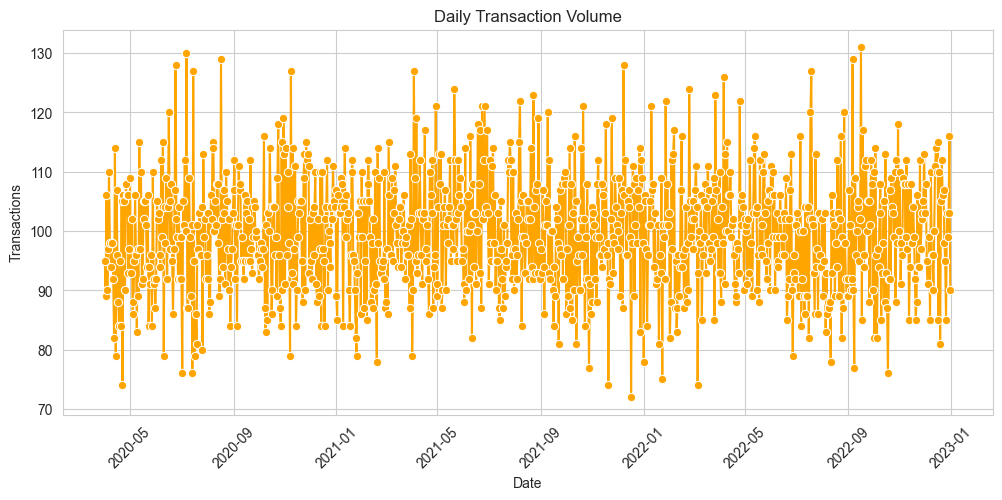

In [92]:
#daily Transaction volume

daily_txn = (upi_Txn.groupby(upi_Txn['transaction_date'].dt.date)['transaction_id'].count().reset_index(name='transactions'))

daily_txn.columns = ['date', 'transactions']

plt.figure(figsize=(12,5))
sns.lineplot(data=daily_txn, x='date', y='transactions', marker='o', color='orange')
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.show()

##### **Insight->Daily transaction volume remained relatively stable throughout the observed period, averaging around 100 transactions per day. While occasional spikes and dips occurred, no significant long-term upward or downward trend was observed, indicating consistent platform usage and transaction activity.**

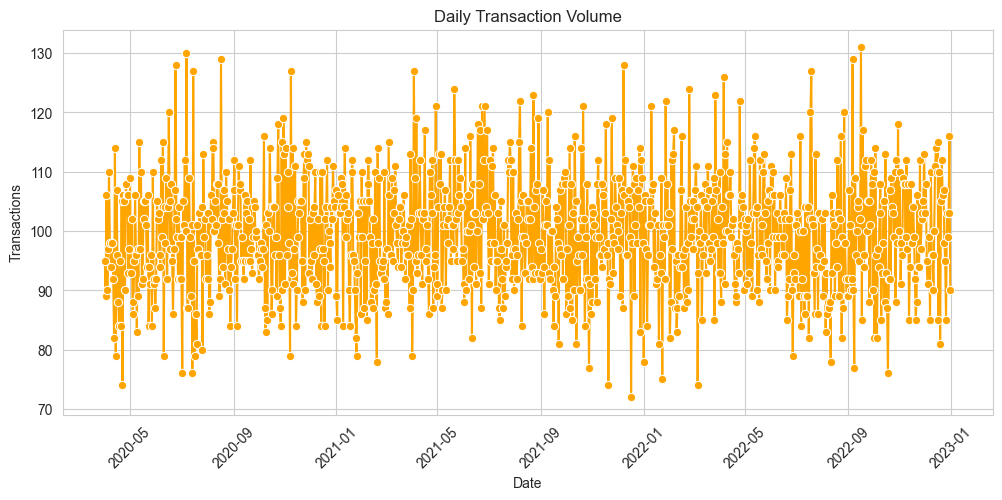

In [97]:
daily_txn = (upi_Txn.groupby(upi_Txn['transaction_date'].dt.date)['transaction_id'].count().reset_index(name='transactions'))

daily_txn.columns = ['date', 'transactions']

daily_txn = daily_txn.sort_values('date')

plt.figure(figsize=(12,5))
sns.lineplot(data=daily_txn, x='date', y='transactions', marker='o', color='orange')

plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.show()

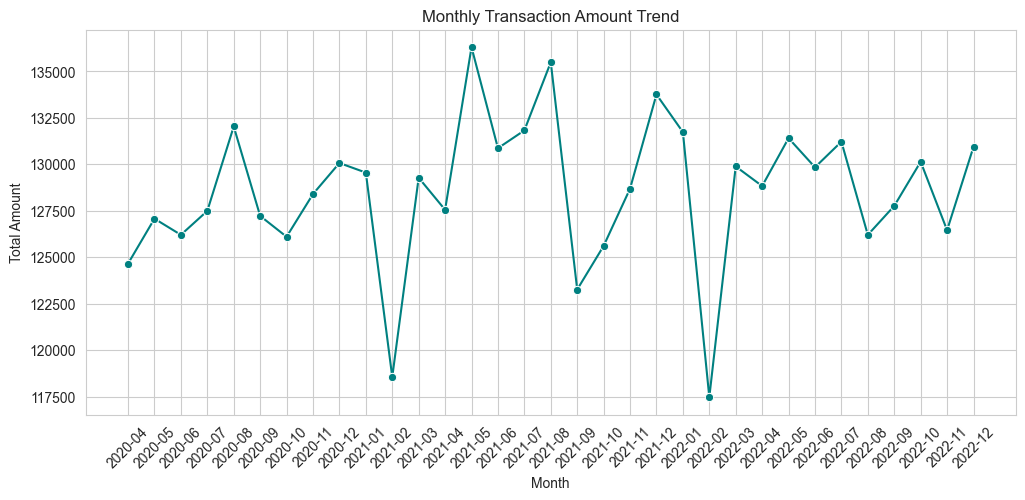

In [99]:
#Monthly Transaction Amount Trend


monthly_amount = (upi_Txn.groupby(upi_Txn['transaction_date'].dt.to_period('M'))['amount'].sum().reset_index(name='total_amount'))

monthly_amount['transaction_date'] = monthly_amount['transaction_date'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_amount,x='transaction_date',y='total_amount',marker='o', color = '#008080')

plt.title('Monthly Transaction Amount Trend')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

##### **Monthly transaction amounts remained relatively stable throughout the analysis period, ranging between approximately ₹118K and ₹136K. Peak transaction values were observed during mid and late 2021, while recurring dips in February suggest seasonal effects, likely due to fewer days in the month and post-festival spending slowdowns**

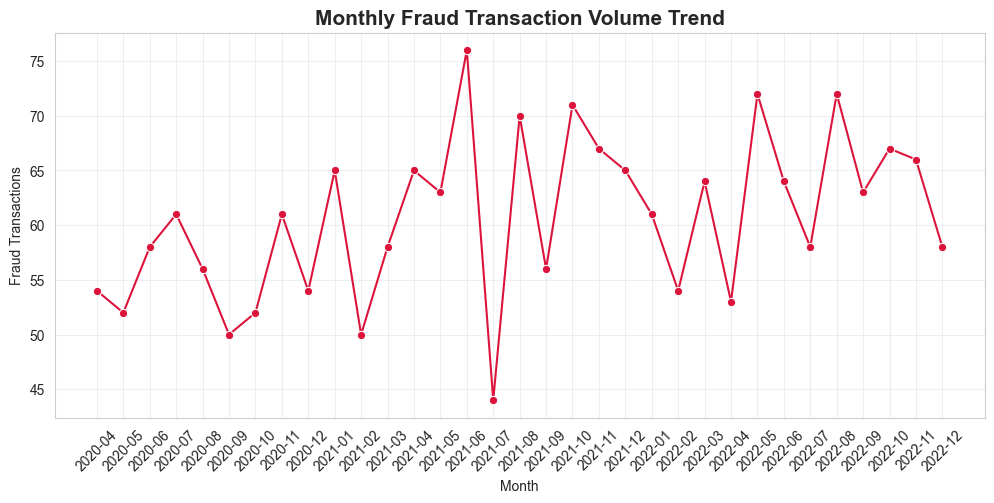

In [101]:
# FRaud Transaction monthly

fraud_txn = upi_Txn[upi_Txn['fraud_flag'] == 1]
monthly_fraud = (fraud_txn.groupby(fraud_txn['transaction_date'].dt.to_period('M'))['transaction_id'].count().reset_index(name='fraud_volume'))
monthly_fraud['transaction_date'] = monthly_fraud['transaction_date'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_fraud,x='transaction_date',y='fraud_volume',marker='o',color='#DC143C')

plt.title('Monthly Fraud Transaction Volume Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fraud Transactions')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

#### **Insight -> Fraud transaction volume exhibited an overall increasing trend from 2020 to 2022, with multiple peaks exceeding 70 fraud transactions per month. The highest fraud activity was recorded in June 2021, while a significant decline was observed in July 2021. Despite fluctuations, fraud incidents remained consistently present throughout the analysis period, highlighting the need for continuous fraud monitoring and enhanced risk management controls.**

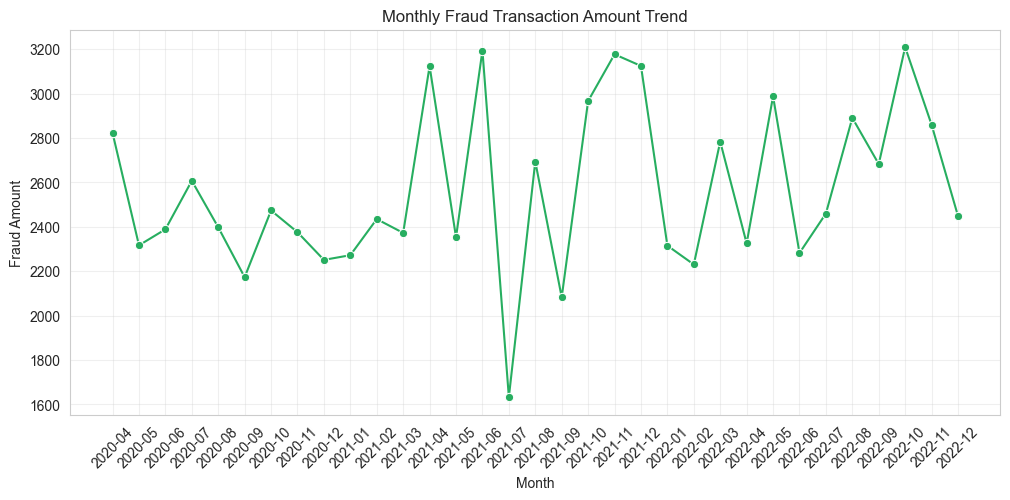

In [103]:
#monthly fraud amount

monthly_fraud_amount = (fraud_txn.groupby(fraud_txn['transaction_date'].dt.to_period('M'))['amount'].sum().reset_index(name='fraud_amount'))

monthly_fraud_amount['transaction_date'] = monthly_fraud_amount['transaction_date'].astype(str)

plt.figure(figsize=(12,5))

sns.lineplot(data=monthly_fraud_amount,x='transaction_date',y='fraud_amount',marker='o',color='#27AE60')

plt.title('Monthly Fraud Transaction Amount Trend')
plt.xlabel('Month')
plt.ylabel('Fraud Amount')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

**##### Insight --> Fraud transaction amounts exhibited considerable volatility throughout the analysis period, ranging from approximately ₹1.6K to ₹3.2K per month. The highest fraud losses were recorded in June 2021, November 2021, and October 2022. While fraud volume remained consistently high, fluctuations in fraud amount indicate varying financial severity of fraudulent transactions. The recurring peaks highlight the need for stronger fraud monitoring and risk mitigation strategies, particularly during high-risk periods.**

In [114]:
Custupimerge = upi_Txn.merge(
    customer_detail[['customer_id','region']],
    on='customer_id',
    how='left')

### **Fraud Distribution by Region**

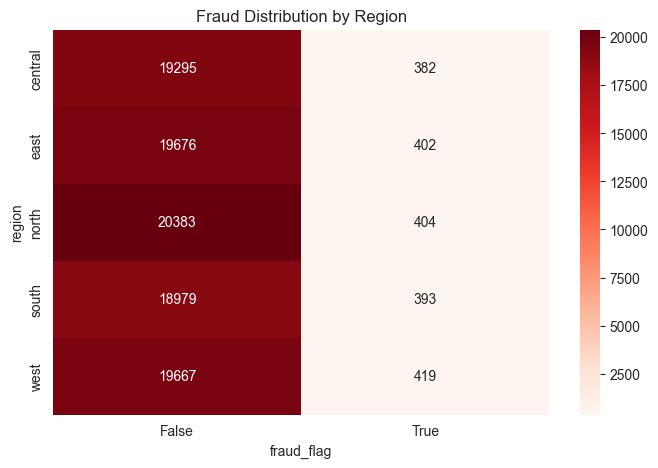

In [116]:
region_fraud = pd.crosstab(Custupimerge['region'],Custupimerge['fraud_flag'])

plt.figure(figsize=(8,5))
sns.heatmap(region_fraud,annot=True,fmt='d',cmap='Reds')
plt.title('Fraud Distribution by Region')
plt.show()

##### **Insight --> Fraudulent transactions were distributed relatively evenly across all regions, indicating that fraud risk is widespread rather than concentrated in a specific geographic area. The West region recorded the highest number of fraud cases (419), while the Central region reported the lowest (382). Fraud rates remained close to 2% across all regions, suggesting a consistent fraud exposure level throughout the network**

#### **Fraud by Device typme**

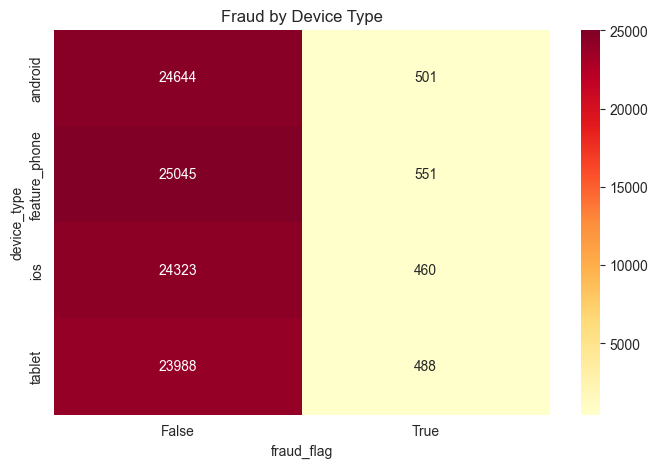

In [117]:
device_fraud = pd.crosstab(upi_Txn['device_type'],upi_Txn['fraud_flag'])

plt.figure(figsize=(8,5))

sns.heatmap(device_fraud,annot=True,fmt='d',cmap='YlOrRd')
plt.title('Fraud by Device Type')
plt.show()

##### **Insight --> Same case here fraudent transaction relatively evenly acroll all device type where featusre phone has maximum and ios has minimum fraud case**

#### **Fraud by Merchant**

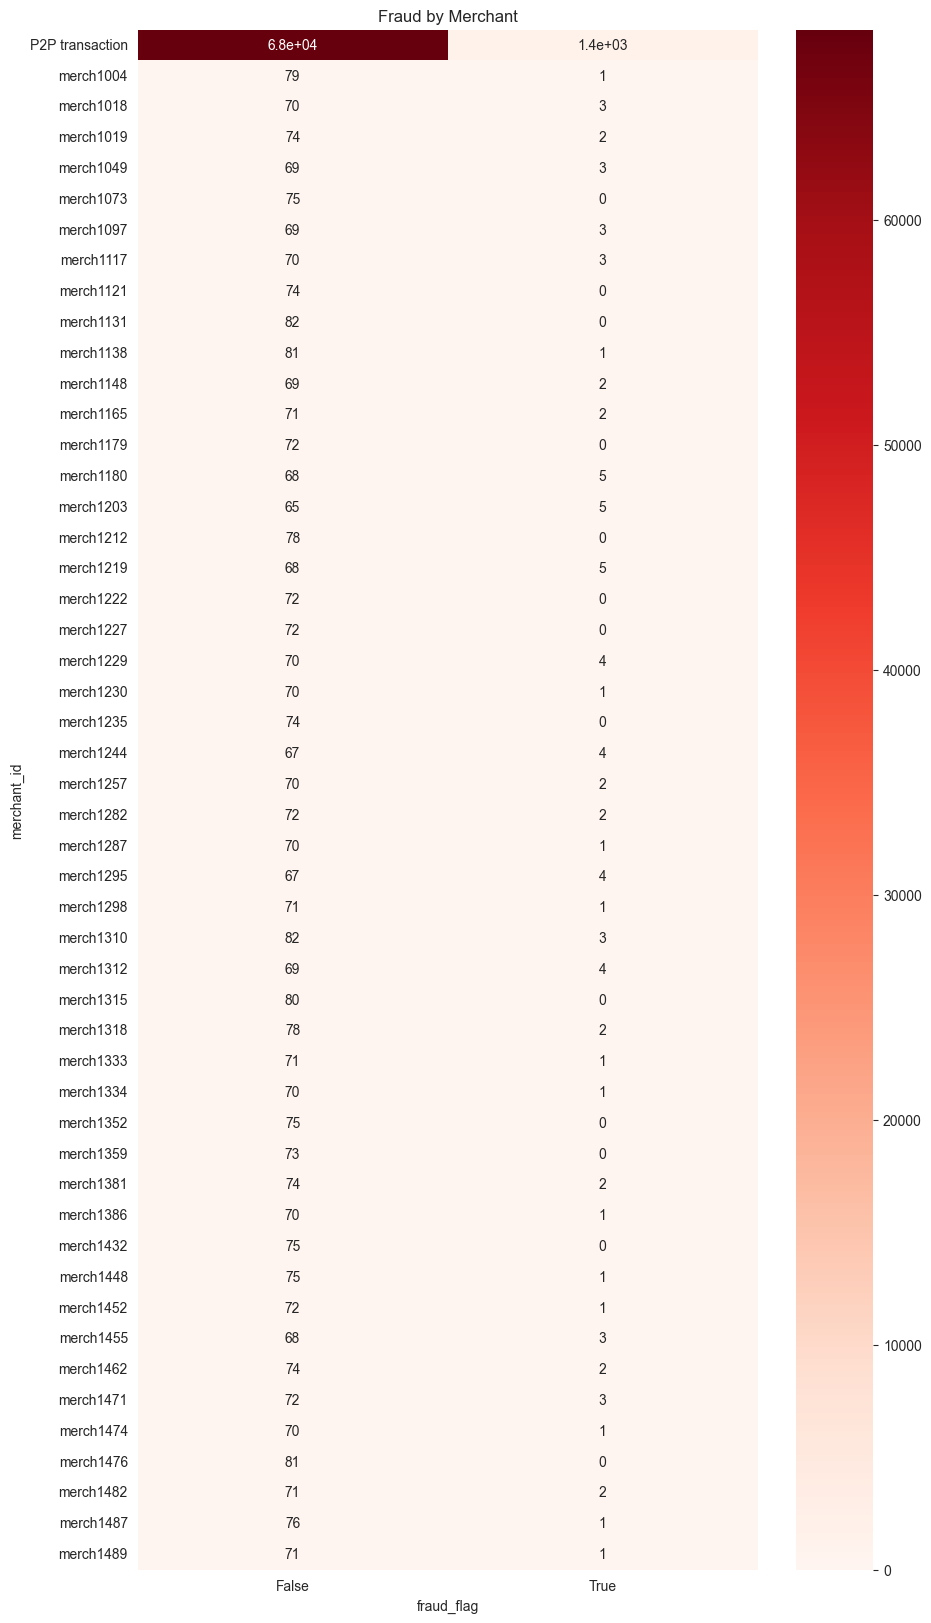

In [122]:
top_merchants = (upi_Txn['merchant_id'].value_counts().head(50).index)

merchant_data = upi_Txn[upi_Txn['merchant_id'].isin(top_merchants)]

merchant_fraud = pd.crosstab(merchant_data['merchant_id'],merchant_data['fraud_flag'])

plt.figure(figsize=(10,20))
sns.heatmap(merchant_fraud,annot=True,cmap='Reds')

plt.title('Fraud by Merchant')
plt.show()

##### **Insight --> Fraud analysis by merchant reveals that P2P transactions contribute the majority of fraudulent activity, significantly exceeding fraud cases associated with individual merchants. Merchant-related fraud is relatively low and dispersed across multiple merchants,**

#### **Boxplot — Amount by Region**

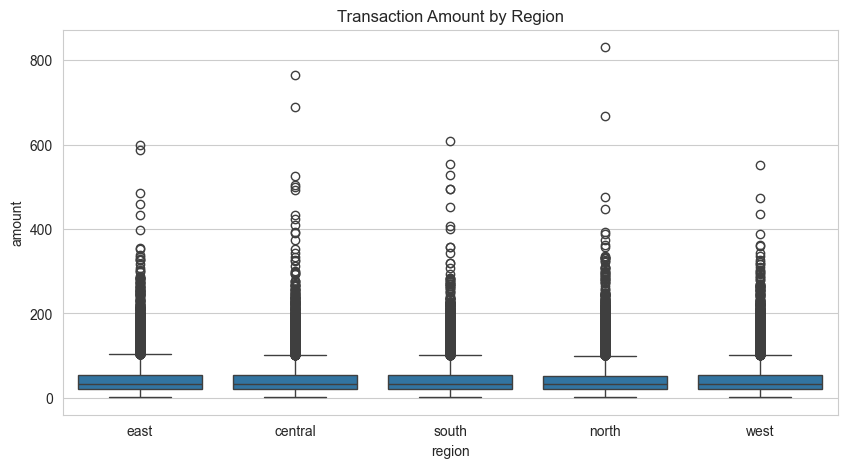

In [123]:
plt.figure(figsize=(10,5))
sns.boxplot(x='region',y='amount',data=Custupimerge)
plt.title('Transaction Amount by Region')
plt.show()

##### **Transaction amount distributions are broadly consistent across all regions, indicating similar customer spending patterns nationwide. The North region recorded the highest transaction amount, suggesting occasional large-value transactions. Overall, regional spending behavior appears balanced**

#### **Boxplot — Amount by Device Type**

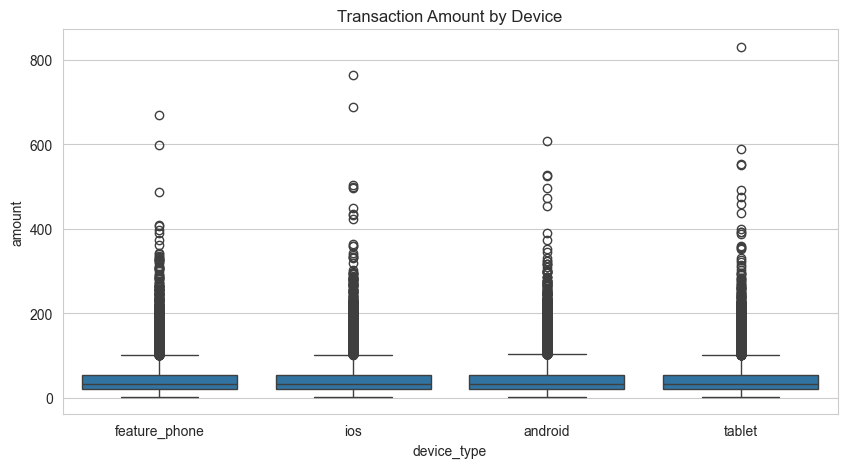

In [124]:
plt.figure(figsize=(10,5))
sns.boxplot(x='device_type',y='amount',data=upi_Txn)
plt.title('Transaction Amount by Device')
plt.show()

##### **Transaction amount distributions are largely consistent across all device types, indicating similar user spending behavior regardless of platform. Most transactions are low-value, while a small number of high-value outliers are observed across all devices. Tablet and iOS users recorded the highest transaction amounts**

#### **Boxplot — Amount vs Fraud**

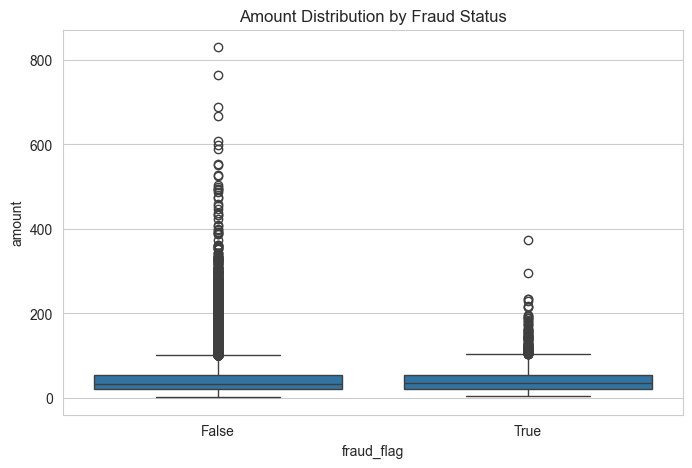

In [125]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud_flag',y='amount',data=upi_Txn)
plt.title('Amount Distribution by Fraud Status')
plt.show()

##### **The distribution of transaction amounts is broadly similar between fraudulent and non-fraudulent transactions. While fraudulent transactions exhibit a slightly higher median value, the highest transaction amounts are associated with legitimate transactions. This suggests that transaction amount alone is insufficient for fraud detection and should be combined with other factors such as device type, region, merchant category, and transaction behavior.**

#### **Transaction Amount by Region**

In [127]:
region_stats = Custupimerge.groupby('region')['amount'].agg(['mean','median','std'])
region_stats.reset_index()

,region,mean,median,std
0,central,42.488194,33.34,34.537385
1,east,42.527747,32.91,34.311902
2,north,42.213204,33.07,34.176362
3,south,42.539278,33.14,34.240232
4,west,42.333227,33.05,33.669879


### **Transaction Amount by Region**

In [128]:
device_stats = upi_Txn.groupby('device_type')['amount'].agg(['mean','median','std'])

device_stats.reset_index()

,device_type,mean,median,std
0,android,42.376283,33.030,34.035585
1,feature_phone,42.216250,32.820,33.981463
2,ios,42.542170,33.090,34.501120
3,tablet,42.545060,33.415,34.233864


### **Transaction Amount by Channel**

In [129]:
channel_stats = upi_Txn.groupby('channel')['amount'].agg(['mean','median','std'])
channel_stats.reset_index()

,channel,mean,median,std
0,app,42.562020,33.21,34.11658
1,intent,42.406557,33.14,34.27906
2,qr_code,42.284304,32.91,34.16259


### **Merchant Risk Score Statistics**

In [130]:
merchant_info.groupby('merchant_type')['risk_score'].agg(['mean','median','std'])

,mean,median,std
merchant_type,,,
apparel,0.178673,0.165,0.117917
electronics,0.169780,0.150,0.122429
food,0.187125,0.180,0.109524
grocery,0.168533,0.150,0.120793
online,0.173372,0.170,0.117259
transport,0.201571,0.220,0.102782


### **Customer Risk Score Statistics**

In [131]:
customer_detail.groupby('region')['risk_score'].agg(['mean','median','std'])

,mean,median,std
region,,,
central,0.207112,0.2,0.118405
east,0.201536,0.2,0.115128
north,0.201091,0.2,0.111858
south,0.203201,0.2,0.115251
west,0.204451,0.2,0.115201


### **High-Activity Customers**

In [134]:
top_customers = (upi_Txn['customer_id'].value_counts().head(25).reset_index())

top_customers.columns = ['customer_id', 'transaction_count']

top_customers.head(10)

,customer_id,transaction_count
0,cust101660,71
1,cust105966,59
2,cust102584,57
3,cust103960,56
4,cust100835,56
5,cust104708,55
6,cust104396,54
7,cust106552,54
8,cust102733,54
9,cust109685,53


### By Transaction Amount

In [137]:
top_customers_amount = (upi_Txn.groupby('customer_id')['amount'].sum().nlargest(10).reset_index())
top_customers_amount.head(10)

,customer_id,amount
0,cust101660,3141.59
1,cust105966,2976.41
2,cust108812,2864.95
3,cust109685,2719.75
4,cust107404,2706.85
5,cust103209,2582.02
6,cust103560,2459.71
7,cust102584,2427.52
8,cust103960,2351.67
9,cust104708,2283.09


### **High-Risk Device Types**

In [138]:
device_risk = upi_Txn.groupby('device_type')['fraud_flag'].mean()

print(device_risk.sort_values(ascending=False))

device_type
feature_phone    0.021527
tablet           0.019938
android          0.019924
ios              0.018561
Name: fraud_flag, dtype: float64


### **High-Risk Merchants**

In [139]:
merchant_risk = (upi_Txn.groupby('merchant_id')['fraud_flag'].mean().mul(100).round(2).nlargest(10))

print(merchant_risk)

merchant_id
merch1201    10.64
merch1305     8.70
merch1358     8.06
merch1080     7.58
merch1364     7.41
merch1203     7.14
merch1231     7.02
merch1307     7.02
merch1051     6.98
merch1180     6.85
Name: fraud_flag, dtype: float64


### **T-tests to compare average transaction amounts across device types**

In [67]:
from scipy.stats import ttest_ind

In [71]:
# Select transaction amounts made from Android devices
android = upi_Txn[upi_Txn['device_type'] == 'android']['amount']

# Select transaction amounts made from iOS devices
ios = upi_Txn[upi_Txn['device_type'] == 'ios']['amount']

# Perform an Independent T-Test to compare the average transaction amounts
t_stat, p_value = ttest_ind(android, ios)

# Display the test results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a statistically significant difference in average transaction amounts between Android and iOS users.")
else:
    print("Fail to Reject H0: There is no statistically significant difference in average transaction amounts between Android and iOS users.")

T-Statistic: -0.5408300925557858
P-Value: 0.5886271119024742
Fail to Reject H0: There is no statistically significant difference in average transaction amounts between Android and iOS users.


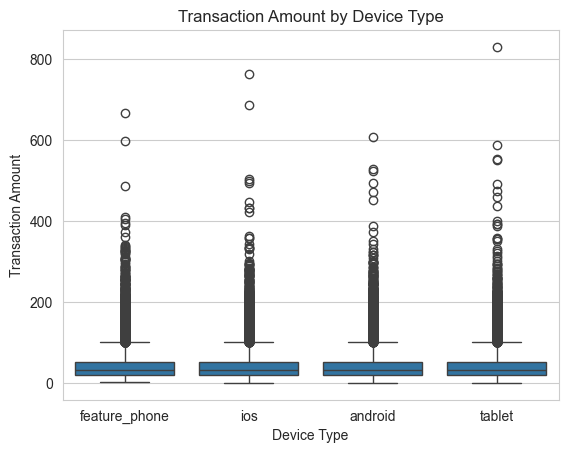

In [94]:
sns.boxplot(data=upi_Txn,x='device_type',y='amount')

plt.title('Transaction Amount by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Transaction Amount')
plt.show()

### **Insight --> The box plot shows substantial overlap in transaction amount distributions across device types, supporting the T-Test result that there is no statistically significant difference in average transaction amounts.**

### **ANOVA to evaluate variability in fraud rates by merchant type**

In [95]:
groups = []
for category in upitxn_merinfo['merchant_type'].dropna().unique():
    data = upitxn_merinfo[category == upitxn_merinfo['merchant_type']]['fraud_flag']
    groups.append(data)

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", round(f_stat, 4))
print("P-Value:", round(p_value, 4))

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Fraud rates vary significantly across merchant types.")
else:
    print("Fail to reject H0")
    print("No significant difference in fraud rates across merchant types.")

F-Statistic: 0.6935
P-Value: 0.6283
Fail to reject H0
No significant difference in fraud rates across merchant types.


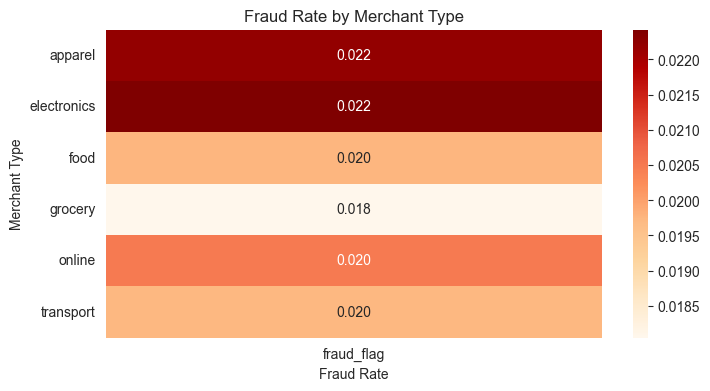

In [97]:
# Calculate average fraud rate for each merchant type
merchant_fraud = upitxn_merinfo.groupby('merchant_type')['fraud_flag'].mean()

# Convert to DataFrame for heatmap
merchant_fraud = merchant_fraud.to_frame()

# Create heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(merchant_fraud,annot=True,fmt='.3f',cmap='OrRd')

plt.title('Fraud Rate by Merchant Type')
plt.xlabel('Fraud Rate')
plt.ylabel('Merchant Type')

plt.show()

### **Interpret --> The heatmap indicates that Electronics and Apparel merchants exhibit the highest fraud rates (approximately 2.2%), while Grocery merchants have the lowest fraud rate (approximately 1.8%). Overall, fraud rates remain relatively consistent across merchant categories, suggesting only minor variation in fraud risk by merchant type.**

### **Chi-square test for associations  between transaction status and device type**

In [93]:
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(
    upi_Txn['status'],
    upi_Txn['device_type']
)

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Transaction Status vary significantly across Device type.")
else:
    print("Fail to reject H0")
    print("No significant difference in Transaction status across device type.")

Chi-Square Statistic: 5.934359154129777
P-Value: 0.4305832999277506
Fail to reject H0
No significant difference in Transaction status across device type.


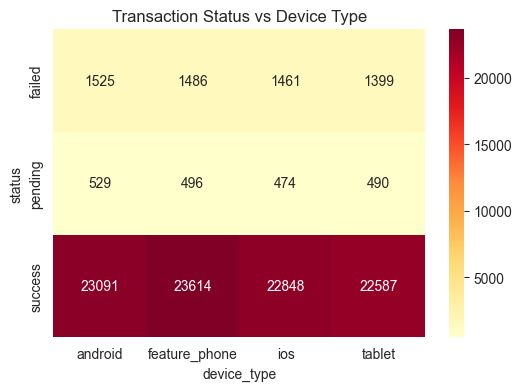

In [104]:
table = pd.crosstab(upi_Txn['status'],upi_Txn['device_type'])

plt.figure(figsize=(6,4))
sns.heatmap(table,annot=True,fmt='d',cmap='YlOrRd')
plt.title('Transaction Status vs Device Type')
plt.show()

### **Interpret-> The heatmap shows that successful, failed, and pending transaction counts are distributed similarly across Android, iOS, Feature Phone, and Tablet devices. This visual evidence aligns with the Chi-Square test result, indicating no significant association between transaction status and device type.**

**Correlation analysis between customer risk_score and transaction/fraud
occurrence**

In [105]:
correlation = upitxn_merinfo['risk_score'].corr(
    upitxn_merinfo['fraud_flag']
)

print("Correlation:", round(correlation, 4))

Correlation: 0.0017


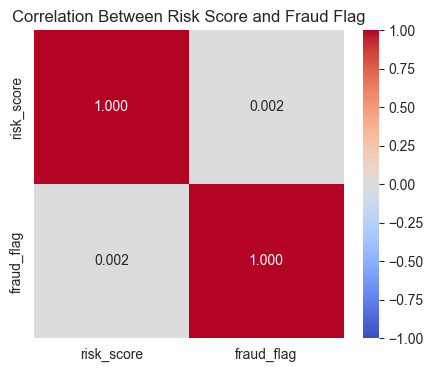

In [108]:
corr_matrix = upitxn_merinfo[['risk_score', 'fraud_flag']].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Risk Score and Fraud Flag')
plt.show()

### **Insight --> Correlation analysis between customer risk score and fraud occurrence produced a correlation coefficient of 0.002, indicating virtually no linear relationship. This suggests that customer risk scores do not significantly influence fraud occurrence in the current dataset.**